# Week 3 Day 1 – Decision Trees and Evaluation

## Learning objectives
- Understand classification models and Decision Trees
- Understand entropy, information gain, and tree splits
- Compare different tree settings
- Evaluate model performance using classification metrics

We use the breast cancer dataset from scikit-learn because it is beginner-friendly and binary classification is ideal for metric interpretation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

%matplotlib inline

### Shared path helper

In [2]:
from pathlib import Path

def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / "requirements.txt").exists() and (candidate / "data").exists():
            return candidate
    return cwd

REPO_ROOT = find_repo_root()
DATASET_PATH = REPO_ROOT / "data" / "week3" / "week3_classification_sample.csv"
DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)


## Load dataset and save CSV copy

In [3]:
data = load_breast_cancer()
feature_names = list(data.feature_names)
target_names = list(data.target_names)

df = pd.DataFrame(data.data, columns=feature_names)
df['target'] = data.target

df.to_csv(DATASET_PATH, index=False)
print('Saved dataset to:', DATASET_PATH)

Saved dataset to: /Users/mehrdadjalali/Documents/SRH-Courses/Modules/Statistics and Machine Learning/Hands-on/Statistics-and-Machine-Learning/data/week3/week3_classification_sample.csv


## Basic exploration
- `shape`: rows and columns
- `head`: first rows
- `value_counts`: class distribution
- missing-value check with `isna().sum()`

In [4]:
print('Shape:', df.shape)
display(df.head())
print('Class distribution (0=malignant, 1=benign):')
print(df['target'].value_counts())
print('\nFeature count:', len(feature_names))
print('Target labels:', target_names)
print('\nMissing values per column:')
print(df.isna().sum().head())

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Class distribution (0=malignant, 1=benign):
target
1    357
0    212
Name: count, dtype: int64

Feature count: 30
Target labels: ['malignant', 'benign']

Missing values per column:
mean radius        0
mean texture       0
mean perimeter     0
mean area          0
mean smoothness    0
dtype: int64


## Train/test split
We split data so we can test generalization on unseen examples.

In [5]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (455, 30)
Test shape: (114, 30)


## Helper function for evaluation metrics

In [6]:
def evaluate_classifier(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    result = {
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'F1-score': f1_score(y_test, y_test_pred),
        'Confusion Matrix': confusion_matrix(y_test, y_test_pred),
        'Model Object': model,
    }
    return result

## Model 1: Default Decision Tree

In [7]:
m1 = evaluate_classifier('Default Tree', DecisionTreeClassifier(random_state=42), X_train, X_test, y_train, y_test)
print(m1['Confusion Matrix'])
print('Accuracy:', round(m1['Test Accuracy'], 3), 'Precision:', round(m1['Precision'], 3), 'Recall:', round(m1['Recall'], 3), 'F1:', round(m1['F1-score'], 3))

[[39  3]
 [ 7 65]]
Accuracy: 0.912 Precision: 0.956 Recall: 0.903 F1: 0.929


## Model 2: Gini criterion
Gini impurity measures class mixing in a node. Lower impurity means cleaner splits.

In [8]:
m2 = evaluate_classifier('Gini depth=4', DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42), X_train, X_test, y_train, y_test)
print(m2['Confusion Matrix'])
print('Accuracy:', round(m2['Test Accuracy'], 3), 'Precision:', round(m2['Precision'], 3), 'Recall:', round(m2['Recall'], 3), 'F1:', round(m2['F1-score'], 3))

[[39  3]
 [ 4 68]]
Accuracy: 0.939 Precision: 0.958 Recall: 0.944 F1: 0.951


## Model 3: Entropy criterion
Entropy is used in ID3-style intuition. Information gain chooses splits that reduce entropy most.

In [9]:
m3 = evaluate_classifier('Entropy depth=4', DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42), X_train, X_test, y_train, y_test)
print(m3['Confusion Matrix'])
print('Accuracy:', round(m3['Test Accuracy'], 3), 'Precision:', round(m3['Precision'], 3), 'Recall:', round(m3['Recall'], 3), 'F1:', round(m3['F1-score'], 3))

[[39  3]
 [ 4 68]]
Accuracy: 0.939 Precision: 0.958 Recall: 0.944 F1: 0.951


## Model 4: Compare depth settings
Deep trees can overfit: training performance goes up, but test performance may stop improving.

In [10]:
depths = [1, 2, 3, 4, 5, None]
depth_rows = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    depth_rows.append({'max_depth': str(d), 'train_accuracy': train_acc, 'test_accuracy': test_acc})

depth_df = pd.DataFrame(depth_rows)
display(depth_df)

,max_depth,train_accuracy,test_accuracy
0,1,0.923077,0.921053
1,2,0.958242,0.894737
2,3,0.975824,0.938596
3,4,0.986813,0.938596
4,5,0.993407,0.921053
5,None,1.000000,0.912281


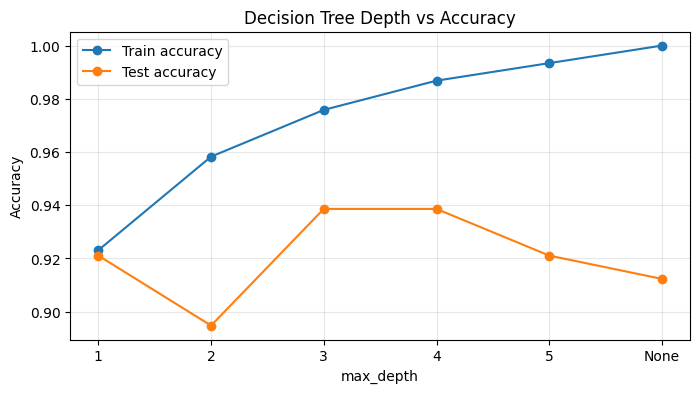

In [11]:
plt.figure(figsize=(8,4))
plt.plot(depth_df['max_depth'], depth_df['train_accuracy'], marker='o', label='Train accuracy')
plt.plot(depth_df['max_depth'], depth_df['test_accuracy'], marker='o', label='Test accuracy')
plt.title('Decision Tree Depth vs Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Feature importance from best test-accuracy tree

,feature,importance
20,worst radius,0.763804
27,worst concave points,0.127061
11,texture error,0.047673
21,worst texture,0.033652
26,worst concavity,0.017869
13,area error,0.009940
0,mean radius,0.000000
16,concavity error,0.000000
28,worst symmetry,0.000000
25,worst compactness,0.000000


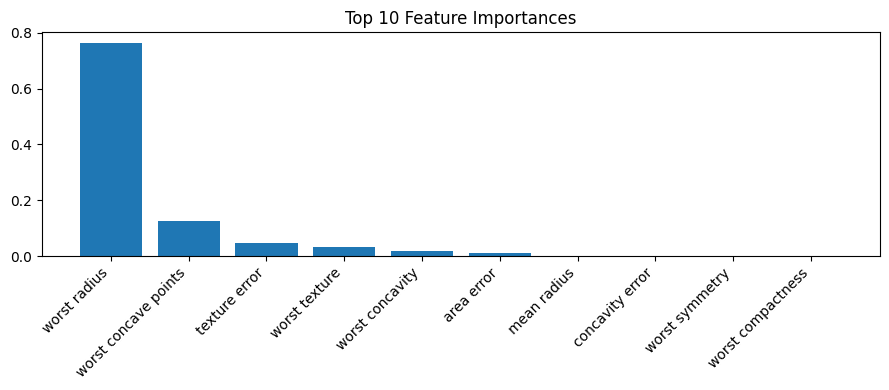

In [12]:
best_depth = depth_df.sort_values('test_accuracy', ascending=False).iloc[0]['max_depth']
best_depth_param = None if best_depth == 'None' else int(best_depth)
best_tree = DecisionTreeClassifier(max_depth=best_depth_param, random_state=42)
best_tree.fit(X_train, y_train)

fi = pd.DataFrame({'feature': feature_names, 'importance': best_tree.feature_importances_}).sort_values('importance', ascending=False)
display(fi.head(10))

plt.figure(figsize=(9,4))
plt.bar(fi.head(10)['feature'], fi.head(10)['importance'])
plt.title('Top 10 Feature Importances')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Visualize a small tree

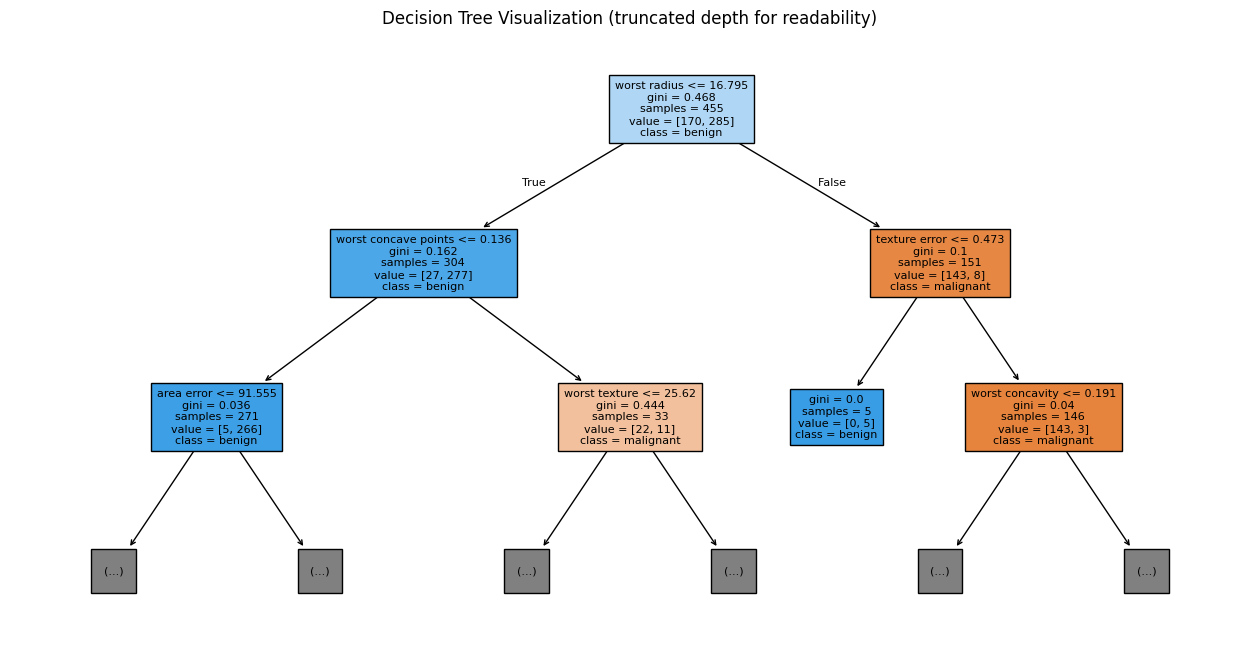

In [13]:
small_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
small_tree.fit(X_train, y_train)

plt.figure(figsize=(16, 8))
plot_tree(small_tree, feature_names=feature_names, class_names=target_names, filled=True, max_depth=2, fontsize=8)
plt.title('Decision Tree Visualization (truncated depth for readability)')
plt.show()

## Summary table for compared tree models

In [14]:
summary = pd.DataFrame([
    {'Model': m1['Model'], 'Criterion': 'default', 'max_depth': 'default', 'Train Accuracy': m1['Train Accuracy'], 'Test Accuracy': m1['Test Accuracy'], 'Precision': m1['Precision'], 'Recall': m1['Recall'], 'F1-score': m1['F1-score']},
    {'Model': m2['Model'], 'Criterion': 'gini', 'max_depth': 4, 'Train Accuracy': m2['Train Accuracy'], 'Test Accuracy': m2['Test Accuracy'], 'Precision': m2['Precision'], 'Recall': m2['Recall'], 'F1-score': m2['F1-score']},
    {'Model': m3['Model'], 'Criterion': 'entropy', 'max_depth': 4, 'Train Accuracy': m3['Train Accuracy'], 'Test Accuracy': m3['Test Accuracy'], 'Precision': m3['Precision'], 'Recall': m3['Recall'], 'F1-score': m3['F1-score']},
]).sort_values('Test Accuracy', ascending=False)
display(summary.round(3))

,Model,Criterion,max_depth,Train Accuracy,Test Accuracy,Precision,Recall,F1-score
1,Gini depth=4,gini,4,0.987,0.939,0.958,0.944,0.951
2,Entropy depth=4,entropy,4,0.985,0.939,0.958,0.944,0.951
0,Default Tree,default,default,1.000,0.912,0.956,0.903,0.929


## Student reflection
- Which tree performed best?
- Did the deepest tree generalize best?
- Why might a simpler tree be better?
- Which metric matters most for this task?

In [15]:
print('Week 3 Day 1 Decision Trees and Evaluation completed successfully.')

Week 3 Day 1 Decision Trees and Evaluation completed successfully.
